In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from models import Route
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END

In [2]:
router_llm = ChatOllama(
    base_url="https://api.ollama.com",
    model="gemma4:31b-cloud",
    temperature=0
)

In [3]:
router = router_llm.with_structured_output(Route)

In [4]:
SUPERVISOR_PROMPT = """
You are the supervisor of a multi-agent personal learning and research assistant.

Your responsibility is to route each user request to exactly one specialized agent.

Available agents:

tutor:
- Explains concepts from the student's course.
- Answers questions using the RAG course knowledge base.
- Handles questions such as "Explain TCP", "What is a semaphore?", or "Explain this course concept."

quiz:
- Generates quizzes based on course content.
- Creates questions and choices from the student's course material.

evaluation:
- Evaluates a student's quiz answers.
- Analyzes quiz performance.
- Identifies mistakes, weak areas, and performance.

planner:
- Creates personalized study plans.
- Uses the student's profile, performance, weak topics, and learning goals.

research:
- Searches the web for scientific information and papers.
- Uses web search and web fetch.
- Handles requests requiring recent or external scientific information.

comparison:
- Compares scientific papers.
- Produces structured comparisons of methodologies, results, strengths, and limitations.

FINISH:
- Use only when the request has already been completed or when no specialized agent is necessary.

Routing rules:

1. Questions about concepts from the student's course should go to tutor.

2. Requests to generate a quiz based on course content should go to quiz.

3. Requests to evaluate quiz answers or analyze quiz performance should go to evaluation.

4. Requests for personalized study plans should go to planner.

5. Requests requiring recent scientific information, web research, or scientific papers should go to research.

6. Requests to compare two or more scientific papers should go to comparison.

7. Choose exactly ONE agent.

8. Do not answer the user's request yourself.

9. The "next" field MUST contain exactly one of:
   - "tutor"
   - "quiz"
   - "evaluation"
   - "planner"
   - "research"
   - "comparison"
   - "FINISH"

10. The "reason" field MUST contain a short explanation of why the selected agent is appropriate.

11. Return ONLY a valid JSON object.

12. Do NOT return Markdown.

13. Do NOT use code fences.

14. Do NOT return text such as:
   "NEXT AGENT: tutor"
   "The next agent is tutor"
   "Agent: tutor"

15. The JSON object MUST have exactly these two fields:
   "next" and "reason".

16. The value of "next" must be one of the allowed agent names listed above.

17. The "reason" should be concise and should explain the routing decision.

Expected output format:

{
    "next": "tutor",
    "reason": "The request asks for an explanation of a course concept."
}
"""

In [5]:
def route_request(user_message: str):

    messages = [
        {
            "role": "system",
            "content": SUPERVISOR_PROMPT
        },
        {
            "role": "user",
            "content": user_message
        }
    ]

    return router.invoke(messages)

In [6]:
decision = route_request(
    "Explain how TCP works."
)

print(decision)

next='tutor' reason="The user is asking for an explanation of a technical concept (TCP), which falls under the tutor agent's responsibility."


In [7]:
decision = route_request(
    "Generate a quiz about TCP."
)

print(decision)

next='quiz' reason='The user is requesting the generation of a quiz based on a specific course topic (TCP).'


In [8]:
decision = route_request(
    "Find recent scientific papers about RAG."
)

print(decision)

next='research' reason='The user is requesting recent scientific papers on a specific topic, which requires web search and retrieval of external scientific information.'


In [9]:
from typing import TypedDict

class SupervisorState(TypedDict):
    user_message: str
    next: str
    response: str

In [10]:
def supervisor_node(state: SupervisorState):

    decision = route_request(
        state["user_message"]
    )

    return {
        "next": decision.next
    }

In [11]:
def tutor_node(state: SupervisorState):

    return {
        "response": "Tutor Agent selected."
    }

def quiz_node(state: SupervisorState):

    return {
        "response": "Quiz Agent selected."
    }

def evaluation_node(state: SupervisorState):

    return {
        "response": "Evaluation Agent selected."
    }

def planner_node(state: SupervisorState):

    return {
        "response": "Planner Agent selected."
    }

def research_node(state: SupervisorState):

    return {
        "response": "Research Agent selected."
    }

def comparison_node(state: SupervisorState):

    return {
        "response": "Comparison Agent selected."
    }

In [12]:
graph_builder = StateGraph(SupervisorState)

graph_builder.add_node(
    "supervisor",
    supervisor_node
)
graph_builder.add_node(
    "tutor",
    tutor_node
)

graph_builder.add_node(
    "quiz",
    quiz_node
)

graph_builder.add_node(
    "evaluation",
    evaluation_node
)

graph_builder.add_node(
    "planner",
    planner_node
)

graph_builder.add_node(
    "research",
    research_node
)

graph_builder.add_node(
    "comparison",
    comparison_node
)

In [13]:
graph_builder.add_edge(
    START,
    "supervisor"
)
graph_builder.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {
        "tutor": "tutor",
        "quiz": "quiz",
        "evaluation": "evaluation",
        "planner": "planner",
        "research": "research",
        "comparison": "comparison",
        "FINISH": END,
    }
)
graph_builder.add_edge(
    "tutor",
    END
)

graph_builder.add_edge(
    "quiz",
    END
)

graph_builder.add_edge(
    "evaluation",
    END
)

graph_builder.add_edge(
    "planner",
    END
)

graph_builder.add_edge(
    "research",
    END
)

graph_builder.add_edge(
    "comparison",
    END
)

In [14]:
supervisor_graph = graph_builder.compile()

In [15]:
result = supervisor_graph.invoke(
    {
        "user_message": "Explain how HTTP works.",
        "next": "",
        "response": ""
    }
)
print(result)

{'user_message': 'Explain how HTTP works.', 'next': 'tutor', 'response': 'Tutor Agent selected.'}


In [16]:
result = supervisor_graph.invoke(
    {
        "user_message": "Generate a quiz about HTTP.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': 'Generate a quiz about HTTP.', 'next': 'quiz', 'response': 'Quiz Agent selected.'}


In [17]:
result = supervisor_graph.invoke(
    {
        "user_message": "Create a study plan for my weak topics.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': 'Create a study plan for my weak topics.', 'next': 'planner', 'response': 'Planner Agent selected.'}


In [18]:
result = supervisor_graph.invoke(
    {
        "user_message": "Find recent papers about RAG.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': 'Find recent papers about RAG.', 'next': 'research', 'response': 'Research Agent selected.'}


In [19]:
result = supervisor_graph.invoke(
    {
        "user_message": "Compare these research papers.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': 'Compare these research papers.', 'next': 'comparison', 'response': 'Comparison Agent selected.'}


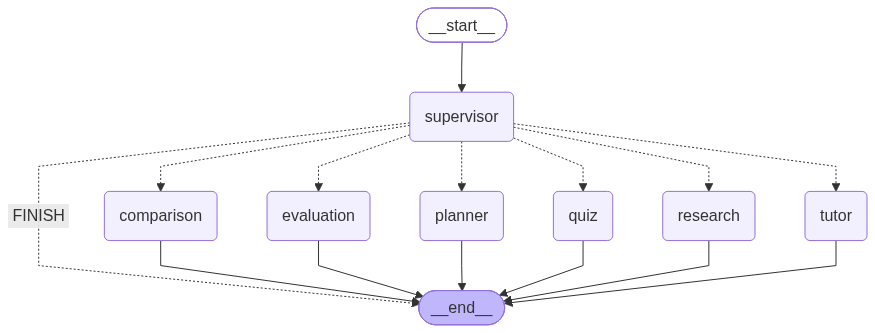

In [20]:
from IPython.display import Image, display

display(
    Image(
        supervisor_graph.get_graph().draw_mermaid_png()
    )
)

In [21]:
result = supervisor_graph.invoke(
    {
        "user_message": "Thank you, that's all.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': "Thank you, that's all.", 'next': 'FINISH', 'response': ''}


In [22]:
import operator

from typing import Annotated, TypedDict, Any

from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    AIMessage,
)

from models import (
    Quiz,
    StudentProfile,
    StudyPlan,
    PaperComparison,
)

from rag import (
    load_vector_store,
    get_llm,
    ask_tutor,
)

In [23]:
class LearningResearchState(TypedDict, total=False):

    # Conversation
    messages: Annotated[list[BaseMessage], operator.add]
    user_message: str

    # Supervisor
    next: str

    # Final response
    response: str

    # Tutor / RAG
    retrieved_documents: list[Any]

    # Quiz
    quiz: Quiz
    student_answers: list[Any]

    # Evaluation
    evaluation: Any

    # Student profile
    student_profile: StudentProfile

    # Study plan
    study_plan: StudyPlan

    # Research
    research_response: str
    research_results: list[dict]

    # Comparison
    comparison: PaperComparison

In [24]:
def create_initial_state(user_message: str, **kwargs):
    return {
        "user_message": user_message,
        "messages": [
            HumanMessage(content=user_message)
        ],
        **kwargs,
    }

In [25]:
state = create_initial_state(
    "Explain HTTP and HTTPS"
)

state

{'user_message': 'Explain HTTP and HTTPS',
 'messages': [HumanMessage(content='Explain HTTP and HTTPS', additional_kwargs={}, response_metadata={})]}

In [26]:
def tutor_node(state: LearningResearchState):

    question = state["user_message"]

    vector_store = load_vector_store()
    tutor_llm = get_llm()

    answer, documents = ask_tutor(
        vector_store=vector_store,
        llm=tutor_llm,
        question=question,
        k=5,
    )

    return {
        "response": answer,
        "retrieved_documents": documents,
        "messages": [
            AIMessage(content=answer)
        ],
    }

In [27]:
test_state = create_initial_state(
    "What is Internet?"
)

result = tutor_node(test_state)

print(result["response"])

c:\Users\LENOVO\Desktop\Personal-Learning-Research-Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2435.32it/s]


Based on the provided course material, the **Internet** is defined as a set of local and wide area networks (LANs and WANs) that are interconnected on an international scale.

Here are a few key details about its structure and ownership:
*   **Connectivity:** Local networks are connected to one another via wide area networks. These wide area networks are then linked using wireless transmissions, fiber optic cables, or copper wires.
*   **Ownership:** The Internet does not belong to any specific person or group.


In [28]:
print(
    "Documents retrieved:",
    len(result["retrieved_documents"])
)

Documents retrieved: 5


In [29]:
llm = ChatOllama(
    base_url="https://api.ollama.com",
    model="gpt-oss:120b-cloud",
    temperature=0
)
from rag import (
    load_vector_store,
    build_context,
    retrieve_documents
)

def build_quiz_prompt(
    context: str,
    topic: str,
    number_of_questions: int = 5
):
    return f"""
You are a university quiz generation assistant.

Generate a quiz based ONLY on the provided course context.

Topic:
{topic}

Number of questions:
{number_of_questions}

IMPORTANT RULES:

1. Use only information supported by the course context.
2. Do not invent concepts that are not present in the context.
3. Questions must test understanding, not only memorization.
4. Use a mixture of question types when appropriate.
5. Multiple-choice questions must contain clear choices.
6. The correct answer must be explicitly supported by the context.
7. Provide a concise explanation for every correct answer.
8. Make the questions appropriate for a university student.
9. Return exactly {number_of_questions} questions.
10. For multiple-choice questions, provide the choices in the choices field.
11. For true/false questions, use the correct_answer field appropriately.
12. For short-answer questions, choices must be an empty list.
13. Do not return Markdown.
14. Do not add introductory or concluding text.
15. Do not write "Correct Answer:" or "Explanation:" outside the corresponding structured fields.
16. Every question MUST contain a topic field.
17. The topic field of every question MUST be exactly:
    "{topic}"
18. Do not omit the topic field from any question.
19. Every question_id MUST be an integer.
20. question_id MUST NOT contain letters.
21. Do NOT use values such as "Q1", "Q2", "Q3", etc.
22. Use sequential integer values starting from 1:
    1, 2, 3, ..., {number_of_questions}.

COURSE CONTEXT:
----------------
{context}
----------------

Generate the quiz according to the required structured output schema.

The root output must be a Quiz object.

The output must contain:
- title
- topic
- questions

The root topic field must be:
"{topic}"

The questions field must contain exactly {number_of_questions} questions.

Do NOT return the questions as a standalone JSON array.

Each question MUST contain ALL of the following fields:
- question_id
- question
- topic
- question_type
- choices
- correct_answer
- explanation

For every question:

- question_id must be an integer.
- question_id must start at 1.
- question_id must increase sequentially.
- For {number_of_questions} questions, the question_id values must be:
  1, 2, 3, ..., {number_of_questions}.
- Never use "Q1", "Q2", "Q3" or any other string as question_id.
- topic must be exactly "{topic}".
- question must be based only on the course context.
- question_type must be one of the allowed values.
- choices must contain options only for multiple-choice questions.
- choices must be an empty list for true/false and short-answer questions.
- correct_answer must contain the correct answer.
- explanation must briefly explain why the answer is correct using information from the course context.

Use these exact question_type values:
- multiple_choice
- true_false
- short_answer

Return only the structured Quiz object.
"""

def generate_quiz(
    vector_store,
    quiz_llm,
    topic: str,
    number_of_questions: int = 5,
    k: int = 5
):
    documents = retrieve_documents(
        vector_store,
        topic,
        k=k
    )

    context = build_context(documents)

    prompt = build_quiz_prompt(
        context=context,
        topic=topic,
        number_of_questions=number_of_questions
    )

    quiz = quiz_llm.invoke(prompt)

    return quiz, documents

In [30]:
from models import Quiz
quiz_llm = llm.with_structured_output(Quiz)

def quiz_node(state: LearningResearchState):

    topic = state["user_message"]

    vector_store = load_vector_store()

    quiz, documents = generate_quiz(
        vector_store=vector_store,
        quiz_llm=quiz_llm,
        topic=topic,
        number_of_questions=5,
        k=5,
    )

    response = (
        f"Quiz generated successfully: "
        f"{quiz.title}"
    )

    return {
        "quiz": quiz,
        "retrieved_documents": documents,
        "response": response,
        "messages": [
            AIMessage(content=response)
        ],
    }

In [31]:
test_state = create_initial_state(
    "Generate a quiz about HTTP"
)

result = quiz_node(test_state)

print(result["response"])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2093.42it/s]


Quiz generated successfully: HTTP Quiz


In [32]:
quiz = result["quiz"]

print("Title:", quiz.title)
print("Topic:", quiz.topic)
print("Number of questions:", len(quiz.questions))

for question in quiz.questions:
    print(
        question.question_id,
        question.question_type,
        question.question
    )

Title: HTTP Quiz
Topic: Generate a quiz about HTTP
Number of questions: 5
1 multiple_choice In the client‑server model described, which device initiates a request to obtain a web page?
2 true_false According to the course context, a server can also act as a client by sending requests to other servers.
3 short_answer Give one example of a server type mentioned in the material.
4 multiple_choice Which of the following Internet connection types is NOT mentioned for home or small‑office use?
5 true_false The document states that HTTP is the protocol used for secure email transmission.


In [33]:
planner_llm = llm.with_structured_output(StudyPlan)

def build_planner_prompt(
    profile: StudentProfile,
    number_of_sessions: int = 3
):
    history = "\n".join(
        [
            (
                f"- {performance.quiz_title}: "
                f"{performance.percentage:.1f}% "
                f"(strong: {performance.strong_topics}, "
                f"weak: {performance.weak_topics})"
            )
            for performance in profile.performance_history
        ]
    )

    return f"""
You are a personalized learning planner for a university student.

Your task is to create an adaptive and personalized study plan based
ONLY on the student's information provided below.

====================
STUDENT PROFILE
====================

Student ID:
{profile.student_id}

Quizzes completed:
{profile.quizzes_completed}

Average score:
{profile.average_score:.2f}

Average percentage:
{profile.average_percentage:.2f}%

Strong topics:
{profile.strong_topics}

Weak topics:
{profile.weak_topics}

====================
PERFORMANCE HISTORY
====================

{history}

====================
PLANNING REQUIREMENTS
====================

1. Create EXACTLY {number_of_sessions} study sessions.

2. Prioritize weak topics over strong topics.

3. Give HIGH priority to weak topics whenever appropriate.

4. Strong topics should receive less study time and should mainly be
   used for maintenance or quick review.

5. Use the student's performance history to adapt the study plan.

6. If a topic repeatedly appears as a weak topic or has low quiz
   performance, give it more attention.

7. The plan should be progressive:
   - begin with reviewing or understanding concepts,
   - continue with practice and application,
   - finish with evaluation or self-assessment whenever appropriate.

8. Each study session must contain:
   - session_number
   - topic
   - objective
   - activities
   - priority
   - estimated_minutes

9. Activities must be concrete and appropriate for a university student.

10. Do NOT invent specific course content, chapters, concepts,
    exercises, technologies, or subjects that are not present in the
    student's profile or performance history.

11. If there are not enough weak topics to fill all sessions, use
    strong topics for maintenance, but give them lower priority and
    shorter study time.

12. The overall goal must summarize what the student should achieve
    through the complete study plan.

13. The plan_summary must briefly explain why the selected topics,
    priorities, and progression were chosen based on the student's
    performance.

====================
OUTPUT FORMAT
====================

Your response MUST be a valid JSON object that matches EXACTLY the
following structure:

{{
  "student_id": "{profile.student_id}",
  "overall_goal": "Overall learning goal of the study plan.",
  "sessions": [
    {{
      "session_number": 1,
      "topic": "Topic name",
      "objective": "Learning objective for this session.",
      "activities": [
        "Activity 1",
        "Activity 2",
        "Activity 3"
      ],
      "priority": "high",
      "estimated_minutes": 60
    }},
    {{
      "session_number": 2,
      "topic": "Topic name",
      "objective": "Learning objective for this session.",
      "activities": [
        "Activity 1",
        "Activity 2",
        "Activity 3"
      ],
      "priority": "medium",
      "estimated_minutes": 45
    }},
    {{
      "session_number": 3,
      "topic": "Topic name",
      "objective": "Learning objective for this session.",
      "activities": [
        "Activity 1",
        "Activity 2",
        "Activity 3"
      ],
      "priority": "low",
      "estimated_minutes": 30
    }}
  ],
  "plan_summary": "Short explanation of why this study plan was created."
}}

====================
STRICT JSON RULES
====================

The output MUST follow these rules:

1. Return ONLY the JSON object.

2. Do NOT write anything before the JSON.

3. Do NOT write anything after the JSON.

4. Do NOT use Markdown.

5. Do NOT use ```json or ``` code fences.

6. Do NOT include comments.

7. Use double quotes for all JSON keys and string values.

8. Do NOT use trailing commas.

9. The top-level JSON object MUST contain exactly these four fields:
   - student_id
   - overall_goal
   - sessions
   - plan_summary

10. Each session MUST contain exactly these six fields:
    - session_number
    - topic
    - objective
    - activities
    - priority
    - estimated_minutes

11. "student_id" MUST be exactly:
    "{profile.student_id}"

12. "sessions" MUST contain EXACTLY {number_of_sessions} session objects.

13. "session_number" must be an integer.

14. "topic" must be a string.

15. "objective" must be a string.

16. "activities" must be an array of strings.

17. "priority" MUST be exactly one of:
    "high"
    "medium"
    "low"

18. "estimated_minutes" must be an integer greater than or equal to 5.

19. "overall_goal" must be a string.

20. "plan_summary" must be a string.

21. Do not add any additional fields.

Before returning the answer, internally verify that:
- the response is valid JSON,
- all required fields are present,
- no extra fields are present,
- exactly {number_of_sessions} sessions are present,
- every session contains all six required fields,
- every priority value is either "high", "medium", or "low",
- every estimated_minutes value is at least 5.

Now generate the personalized study plan.
"""

def generate_study_plan(
    profile: StudentProfile,
    planner_llm,
    number_of_sessions: int = 3
):
    prompt = build_planner_prompt(
        profile=profile,
        number_of_sessions=number_of_sessions
    )

    study_plan = planner_llm.invoke(prompt)

    return study_plan

In [34]:
def planner_node(state: LearningResearchState):

    profile = state.get("student_profile")

    if profile is None:

        response = (
            "No student profile is available yet. "
            "Complete at least one learning activity "
            "so that a personalized study plan can be generated."
        )

        return {
            "response": response,
            "messages": [
                AIMessage(content=response)
            ],
        }

    study_plan = generate_study_plan(
        profile=profile,
        planner_llm=planner_llm,
        number_of_sessions=3,
    )

    response = (
        f"Study plan generated successfully "
        f"for student {study_plan.student_id}."
    )

    return {
        "study_plan": study_plan,
        "response": response,
        "messages": [
            AIMessage(content=response)
        ],
    }

In [35]:
test_profile = StudentProfile(
    student_id="student_001",
    quizzes_completed=3,
    average_score=7,
    average_percentage=70.0,
    strong_topics=["Internet"],
    weak_topics=["Intranet", "Extranet"],
    performance_history=[],
)
test_state = create_initial_state(
    "Create a personalized study plan",
    student_profile=test_profile,
)

result = planner_node(test_state)

print(result["response"])

Study plan generated successfully for student student_001.


In [36]:
plan = result["study_plan"]

for session in plan.sessions:
    print(
        session.session_number,
        session.topic,
        session.priority,
        session.estimated_minutes
    )

1 Intranet high 60
2 Extranet high 45
3 Internet low 30


In [37]:
from langchain.agents import create_agent
from tools import web_search, web_fetch
research_tools = [
    web_search,
    web_fetch,
]

research_agent = create_agent(
    model=llm,
    tools=research_tools,
    system_prompt="""
You are a scientific research assistant.

Your role is to help students research scientific and
technical topics using reliable web sources.

You have access to two tools:

- web_search: search the web for relevant information.
- web_fetch: retrieve the content of a web page.

Rules:

1. Use web_search when the user asks for current,
   external, or scientific information that is not
   available in the student's course documents.

2. Use web_fetch when you need more information from
   a specific source found during the search.

3. Prefer relevant and trustworthy sources.

4. Clearly distinguish information obtained from web
   sources from information already available in the
   student's course material.

5. Do not invent sources, URLs, authors, or scientific
   results.

6. When possible, mention the sources used.

7. Give clear and structured answers suitable for a
   university student.
"""
)

print("Research Agent créé avec succès !")

Research Agent créé avec succès !


In [38]:
def research_node(state: LearningResearchState):

    user_message = state["user_message"]

    result = research_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_message,
                }
            ]
        }
    )

    messages = result["messages"]

    # Chercher le dernier message de l'agent
    final_response = ""

    for message in reversed(messages):

        if isinstance(message, AIMessage):

            if message.content:
                final_response = message.content
                break

    return {
        "research_response": final_response,
        "response": final_response,
        "messages": [
            AIMessage(content=final_response)
        ],
    }

In [39]:
test_state = create_initial_state(
    "Find recent scientific papers about large language models."
)

result = research_node(test_state)

print(result["response"])

Below is a short, curated list of **recent (2023‑2024) peer‑reviewed papers that focus on large language models (LLMs)**.  For each entry I include the full citation, a one‑sentence summary of the main contribution, and a direct link to the paper (or its PDF) so you can download it right away.

| # | Paper | Venue & Year | Main contribution | Link |
|---|-------|--------------|-------------------|------|
| 1 | **GPT‑4 Technical Report** – *OpenAI* | arXiv pre‑print (also posted on OpenAI’s blog), Dec 2023 | Describes the architecture, training data, scaling behavior, multimodal capabilities, and extensive safety evaluations of GPT‑4, a 1‑trillion‑parameter multimodal LLM. | https://arxiv.org/pdf/2303.08774.pdf |
| 2 | **Metacognitive Prompting Improves Understanding in Large Language Models** – Wang et al. | NAACL 2024 (Long Papers) | Introduces *Metacognitive Prompting* (MP), a five‑stage prompting strategy that forces LLMs to introspect on their reasoning, yielding consistent gains o

In [40]:
def extract_research_papers(messages):

    papers = []

    for message in messages:

        if message.__class__.__name__ != "ToolMessage":
            continue

        content = message.content

        if isinstance(content, list):

            for item in content:

                if isinstance(item, dict):

                    if "url" in item:
                        papers.append(item)

        elif isinstance(content, dict):

            if "url" in content:
                papers.append(content)

    return papers

In [41]:
def research_node(state: LearningResearchState):

    user_message = state["user_message"]

    result = research_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_message,
                }
            ]
        }
    )

    messages = result["messages"]

    final_response = ""

    for message in reversed(messages):

        if isinstance(message, AIMessage):

            if message.content:
                final_response = message.content
                break

    papers = extract_research_papers(messages)
    
    compare_requested = any(
    word in user_message.lower()
    for word in [
        "compare",
        "comparison",
        "comparaison",
        "comparer",
    ]
    )

    next_step = (
    "comparison"
    if compare_requested and len(papers) >= 2
    else "FINISH"
    )

    return {
        "research_response": final_response,
        "research_results": papers,
        "response": final_response,
        "next": next_step,
        "messages": [
            AIMessage(content=final_response)
        ],
    }

In [42]:
test_state = create_initial_state(
    "Find recent scientific papers about RAG."
)

result = research_node(test_state)

print(result["response"])

print(
    "Number of structured papers:",
    len(result.get("research_results", []))
)

Below is a short, citation‑rich bibliography of **recent (2023‑2024) research papers that focus on Retrieval‑Augmented Generation (RAG)**.  For each entry I give the title, authors, venue/year, a one‑sentence summary of the main contribution, and a link to the full paper.

| # | Paper | Venue / Year | Core Idea | Link |
|---|-------|--------------|----------|------|
| 1 | **Active Retrieval‑Augmented Generation** | *EMNLP 2023* (Dec 2023) | Proposes **FLARE**, a forward‑looking active retrieval method that predicts the next sentence, checks its confidence, and only retrieves when needed, achieving strong results on long‑form QA, commonsense reasoning, and summarisation. | https://aclanthology.org/2023.emnlp-main.495.pdf |
| 2 | **Stochastic RAG: End‑to‑End Retrieval‑Augmented Generation through Expected Utility Maximization** | *SIGIR 2024* (July 2024) | Introduces a differentiable “Gumbel‑top‑k” sampling formulation that lets the retriever be trained jointly with the generator by maxi

In [43]:
comparison_llm = llm.with_structured_output(PaperComparison)

def build_comparison_prompt(
    papers_context: str,
    research_question: str
):
    return f"""
You are a scientific paper comparison assistant.

Your task is to analyze and compare scientific papers using ONLY
the information provided in the paper context.

====================
RESEARCH QUESTION
====================

{research_question}

====================
PAPERS
====================

{papers_context}

====================
ANALYSIS REQUIREMENTS
====================

1. Analyze all papers provided in the context.

2. Extract a structured summary for each paper, including:
   - title
   - authors
   - year
   - research_problem
   - methodology
   - dataset
   - main_results
   - strengths
   - limitations

3. Identify important similarities and differences between the papers.

4. Compare their research problems, methodologies, datasets,
   reported results, strengths, and limitations.

5. Compare numerical results only when the evaluation metrics,
   datasets, and experimental settings are sufficiently comparable.

6. If results cannot be compared directly, explain why.

7. Use only information supported by the provided context.
   Do not invent authors, publication years, datasets, methods,
   numerical results, strengths, or limitations.

8. Distinguish explicitly reported facts from reasonable
   interpretations based on the provided information.

9. If information is missing, state "Not available in the provided
   context." for string fields. For list fields, use an empty list
   when no reliable information is available.

10. Preserve the original meaning of the papers. Do not exaggerate
    their contributions or claim that one approach is superior
    without supporting evidence.

11. The overall conclusion MUST directly answer the research question.

12. Provide a concise but informative scientific comparison.

====================
STRICT OUTPUT FORMAT
====================

Return ONLY one valid JSON object compatible with the
PaperComparison Pydantic model.

The top-level object MUST contain exactly these seven fields:

- papers
- comparison_points
- methodology_comparison
- results_comparison
- strengths_comparison
- limitations_comparison
- overall_conclusion

The "papers" field MUST be an array containing one PaperSummary
object for EACH paper provided in the context.

Each PaperSummary object MUST contain exactly these nine fields:

- title: string
- authors: array of strings
- year: string
- research_problem: string
- methodology: string
- dataset: string
- main_results: string
- strengths: array of strings
- limitations: array of strings

The other fields MUST have the following types:

- comparison_points: array of strings
- methodology_comparison: string
- results_comparison: string
- strengths_comparison: string
- limitations_comparison: string
- overall_conclusion: string

====================
JSON TEMPLATE
====================

Use the following structure as a guide. Replace all example values
with information grounded in the provided papers.

{{
  "papers": [
    {{
      "title": "Paper title",
      "authors": ["Author name"],
      "year": "Publication year",
      "research_problem": "Research problem addressed",
      "methodology": "Methodology used",
      "dataset": "Dataset or data used",
      "main_results": "Main reported results",
      "strengths": ["Evidence-supported strength"],
      "limitations": ["Evidence-supported limitation"]
    }}
  ],
  "comparison_points": [
    "Important similarity or difference between the papers"
  ],
  "methodology_comparison": "Compare the methodologies.",
  "results_comparison": "Compare the reported results and explain any limitations to direct comparison.",
  "strengths_comparison": "Compare the supported strengths.",
  "limitations_comparison": "Compare the supported limitations.",
  "overall_conclusion": "Answer the research question using evidence from the papers."
}}

====================
STRICT JSON RULES
====================

1. Return ONLY the JSON object.
2. Do not include Markdown or Markdown headings.
3. Do not use ```json or any other code fences.
4. Do not write introductory text before the JSON.
5. Do not write explanations after the JSON.
6. Use double quotes for all keys and string values.
7. Do not use trailing commas.
8. Do not include comments in the JSON.
9. Use [] for unavailable list fields; never use null.
10. Use strings for all string fields; never use null.
11. Do not add fields that are not defined in PaperComparison
    or PaperSummary.
12. Include every required field, even when information is missing.
13. The "papers" array must include all papers supplied in the context.
14. Ensure every paper summary follows the exact PaperSummary schema.

Before responding, verify that the output is valid JSON and that
all required fields and data types match the specified schema.

Now generate the scientific paper comparison.
"""

def compare_papers(
    papers: list[dict],
    research_question: str,
    comparison_llm
):
    papers_context = build_papers_context(papers)

    prompt = build_comparison_prompt(
        papers_context=papers_context,
        research_question=research_question
    )

    comparison = comparison_llm.invoke(prompt)

    return comparison

In [44]:
def comparison_node(state: LearningResearchState):

    papers = state.get("research_results", [])

    if len(papers) < 2:

        response = (
            "At least two structured research papers "
            "are required for comparison."
        )

        return {
            "response": response,
            "messages": [
                AIMessage(content=response)
            ],
        }

    research_question = state["user_message"]

    comparison = compare_papers(
        papers=papers,
        research_question=research_question,
        comparison_llm=comparison_llm,
    )

    response = comparison.overall_conclusion

    return {
        "comparison": comparison,
        "response": response,
        "messages": [
            AIMessage(content=response)
        ],
    }

In [45]:
SUPERVISOR_PROMPT = """
You are the supervisor of a multi-agent personal learning and research assistant.

Your responsibility is to route each user request to exactly one specialized agent.

Available agents:

tutor:
- Explains concepts from the student's course.
- Answers questions using the RAG course knowledge base.
- Handles questions such as "Explain TCP", "What is a semaphore?", or "Explain this course concept."

quiz:
- Generates quizzes based on course content.
- Creates questions and choices from the student's course material.

evaluation:
- Evaluates a student's quiz answers.
- Analyzes quiz performance.
- Identifies mistakes, weak areas, and performance.

planner:
- Creates personalized study plans.
- Uses the student's profile, performance, weak topics, and learning goals.

research:
- Searches the web for scientific information and papers.
- Uses web search and web fetch.
- Handles requests requiring recent or external scientific information.

comparison:
- Compares scientific papers.
- Produces structured comparisons of methodologies, results, strengths, and limitations.

FINISH:
- Use only when the request has already been completed or when no specialized agent is necessary.

Routing rules:

1. Questions about concepts from the student's course should go to tutor.

2. Requests to generate a quiz based on course content should go to quiz.

3. Requests to evaluate quiz answers or analyze quiz performance should go to evaluation.

4. Requests for personalized study plans should go to planner.

5. Requests requiring recent scientific information, web research, or scientific papers should go to research.

6. Requests to compare two or more scientific papers should go to comparison.

7. Choose exactly ONE agent.

8. Do not answer the user's request yourself.

9. The "next" field MUST contain exactly one of:
   - "tutor"
   - "quiz"
   - "evaluation"
   - "planner"
   - "research"
   - "comparison"
   - "FINISH"

10. The "reason" field MUST contain a short explanation of why the selected agent is appropriate.

11. Return ONLY a valid JSON object.

12. Do NOT return Markdown.

13. Do NOT use code fences.

14. Do NOT return text such as:
   "NEXT AGENT: tutor"
   "The next agent is tutor"
   "Agent: tutor"

15. The JSON object MUST have exactly these two fields:
   "next" and "reason".

16. The value of "next" must be one of the allowed agent names listed above.

17. The "reason" should be concise and should explain the routing decision.

18. Research and comparison rule:
     - If the user asks to compare scientific papers and no research
  sources are currently available, route to research first.
     - If research sources are already available and the user asks
  for a comparison, route to comparison.
  
Expected output format:

{
    "next": "tutor",
    "reason": "The request asks for an explanation of a course concept."
}
"""

In [46]:
def route_request(
    user_message: str,
    has_research_results: bool = False,
):

    research_status = (
        "Research sources are already available."
        if has_research_results
        else "No research sources are currently available."
    )

    messages = [
        {
            "role": "system",
            "content": SUPERVISOR_PROMPT
            + f"\n\nCurrent state:\n{research_status}"
        },
        {
            "role": "user",
            "content": user_message
        }
    ]

    return router.invoke(messages)

In [47]:
def supervisor_node(state: LearningResearchState):

    decision = route_request(
        user_message=state["user_message"],
        has_research_results=bool(
            state.get("research_results")
        ),
    )

    return {
        "next": decision.next
    }

In [48]:
graph_builder = StateGraph(
    LearningResearchState
)
graph_builder.add_node(
    "supervisor",
    supervisor_node
)

graph_builder.add_node(
    "tutor",
    tutor_node
)

graph_builder.add_node(
    "quiz",
    quiz_node
)

graph_builder.add_node(
    "evaluation",
    evaluation_node
)

graph_builder.add_node(
    "planner",
    planner_node
)

graph_builder.add_node(
    "research",
    research_node
)

graph_builder.add_node(
    "comparison",
    comparison_node
)

graph_builder.add_edge(
    START,
    "supervisor"
)
graph_builder.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {
        "tutor": "tutor",
        "quiz": "quiz",
        "evaluation": "evaluation",
        "planner": "planner",
        "research": "research",
        "comparison": "comparison",
        "FINISH": END,
    }
)
graph_builder.add_edge(
    "tutor",
    END
)

graph_builder.add_edge(
    "quiz",
    END
)

graph_builder.add_edge(
    "evaluation",
    END
)

graph_builder.add_edge(
    "planner",
    END
)

In [49]:
def route_after_research(state: LearningResearchState):

    return state.get("next", "FINISH")

graph_builder.add_conditional_edges(
    "research",
    route_after_research,
    {
        "comparison": "comparison",
        "FINISH": END,
    }
)

graph_builder.add_edge(
    "comparison",
    END
)

In [50]:
learning_graph = graph_builder.compile()

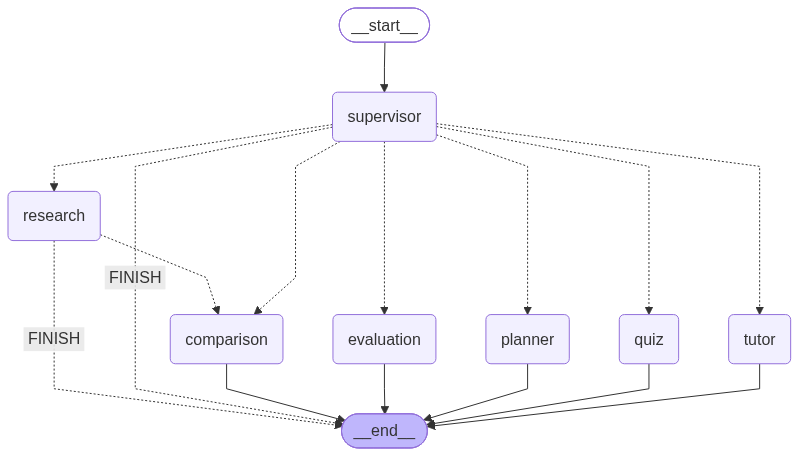

In [51]:
from IPython.display import Image, display

display(
    Image(
        learning_graph
        .get_graph()
        .draw_mermaid_png()
    )
)

In [52]:
state = create_initial_state(
    "Explain Internet"
)

result = learning_graph.invoke(state)

print(result["response"])

print(
    "Next agent:",
    result.get("next")
)

print(
    "Retrieved documents:",
    len(result.get("retrieved_documents", []))
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16692.30it/s]


Based on the provided course material, the **Internet** can be explained as follows:

**Definition and Structure**
The Internet is a global collection of interconnected local area networks (LANs) and wide area networks (WANs). Its structure works as follows:
*   **Interconnection:** Local networks are connected to one another via wide area networks.
*   **Physical Connectivity:** These wide area networks are then linked together using various mediums, such as copper wires, fiber optic cables, or wireless transmissions.
*   **Ownership:** A key characteristic of the Internet is that it does not belong to any single person or specific group.

**Internet vs. Intranets and Extranets**
It is important to distinguish the Internet from other types of network connections:
*   **Intranet:** Unlike the Internet, an intranet is a private connection of LANs and WANs within a company. It is designed to be accessible only to company members or authorized third parties.
*   **Extranet:** A company ma

In [53]:
state = create_initial_state(
    "Generate a quiz about HTTP"
)

result = learning_graph.invoke(state)

print(result["response"])

print(
    "Quiz:",
    result.get("quiz")
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2373.44it/s]


Quiz generated successfully: HTTP Quiz
Quiz: title='HTTP Quiz' topic='Generate a quiz about HTTP' questions=[QuizQuestion(question_id=1, question='Which of the following best describes the role of a client in a client‑server model?', question_type='multiple_choice', choices=['Provides resources to other devices', 'Sends requests to servers to retrieve information', 'Stores files for other devices', 'Routes packets between networks'], correct_answer='Sends requests to servers to retrieve information', explanation='The context states that clients are computers that send requests to servers to retrieve information such as a web page.', topic='Generate a quiz about HTTP'), QuizQuestion(question_id=2, question='In the described network model, a web server can also act as a client.', question_type='true_false', choices=[], correct_answer=True, explanation='The course notes explain that host devices can be used as clients, servers, or both.', topic='Generate a quiz about HTTP'), QuizQuestion(

In [54]:
print(
    "Number of questions:",
    len(result["quiz"].questions)
)

Number of questions: 5


In [55]:
state = create_initial_state(
    "Create my personalized study plan",
    student_profile=test_profile,
)

result = learning_graph.invoke(state)

print(result["response"])

print(
    result["study_plan"]
)

Study plan generated successfully for student student_001.
student_id='student_001' overall_goal='Strengthen understanding and application of Intranet and Extranet concepts while maintaining proficiency in Internet topics to improve overall quiz performance.' sessions=[StudySession(session_number=1, topic='Intranet', objective='Build a solid conceptual foundation of Intranet architecture, purpose, and key components.', activities=['Review lecture slides and textbook sections covering Intranet architecture.', 'Summarize the main differences between Intranet and Internet in a one‑page note.', 'Complete 5 practice questions from the quiz bank focusing on Intranet scenarios.'], priority='high', estimated_minutes=60), StudySession(session_number=2, topic='Extranet', objective='Develop practical skills for configuring and securing Extranet connections and services.', activities=['Watch the recorded tutorial on Extranet security models and access controls.', 'Create a short case‑study analysi

In [56]:
state = create_initial_state(
    "Find recent scientific papers about RAG"
)

result = learning_graph.invoke(state)

print(result["response"])

print(
    "Research papers:",
    len(result.get("research_results", []))
)

**Recent scientific papers on Retrieval‑Augmented Generation (RAG)**  
*(all papers are from 2023‑2024 and are available openly on arXiv or the conference proceedings)*  

| # | Title | Venue / Year | Authors | Core contribution (2‑3 sentence TL;DR) | Link |
|---|-------|---------------|--------|--------------------------------------|------|
| 1 | **Active Retrieval‑Augmented Generation** | EMNLP 2023 (Findings) | Zhengbao Jiang, Frank F. Xu, Luyu Gao, Zhiqing Sun, et al. | Proposes **FLARE**, a forward‑looking active‑retrieval framework that predicts the next sentence, checks its confidence, and only then issues a retrieval query. Shows large gains on long‑form QA, commonsense reasoning, and open‑domain summarisation. | https://aclanthology.org/2023.emnlp-main.495.pdf |
| 2 | **Stochastic RAG: End‑to‑End Retrieval‑Augmented Generation through Expected Utility Maximization** | SIGIR 2024 | Hamed Zamani, Michael Bendersky | Casts retrieval as a *sampling‑without‑replacement* process and

In [57]:
state = create_initial_state(
    "Find recent scientific papers about RAG and compare them"
)

result = learning_graph.invoke(state)

print(result["response"])

**Retrieval‑Augmented Generation (RAG) – a quick snapshot of the field (2023‑2024)**  

| Year | Paper (venue) | Core Idea | What problem it tackles | Main technical ingredients | Typical backbone / Retriever | Reported gains (relative to a strong baseline) | Key strengths | Main limitations / open questions |
|------|----------------|-----------|------------------------|------------------------------|------------------------------|----------------------------------------------|----------------|-----------------------------------|
| 2024 NeurIPS | **Stochastic RAG** (Jiang et al.) | End‑to‑end differentiable RAG by **maximising expected utility** of the generated answer. | The non‑differentiable “retrieve‑then‑generate” pipeline (top‑k retrieval + LM) makes it hard to jointly optimise retriever and generator. | 1️⃣ Treat retrieval as **sampling‑without‑replacement** via a *straight‑through Gumbel‑top‑k* trick. 2️⃣ Two‑stage training: (i) **paraphrase pre‑training** (project retrieval e